In [31]:
import httpx
import time
import torchvision.transforms as tf
import torch
from PIL import Image
import numpy as np
import os
import sys
from PIL import ImageDraw
import requests
import json

In [32]:
def draw_bounding_box_on_image(image,ymin,xmin,ymax,xmax,classification):
    color_map = { 1: 'red', 2: 'blue', 3: 'yellow' }
    color = color_map.get(classification)
    draw = ImageDraw.Draw(image)
    im_width, im_height = image.size
    (left, right, top, bottom) = (xmin * im_width, xmax * im_width,
                                  ymin * im_height, ymax * im_height)
    draw.line([(left, top), (left, bottom), (right, bottom),
               (right, top), (left, top)], width=4, fill=color)

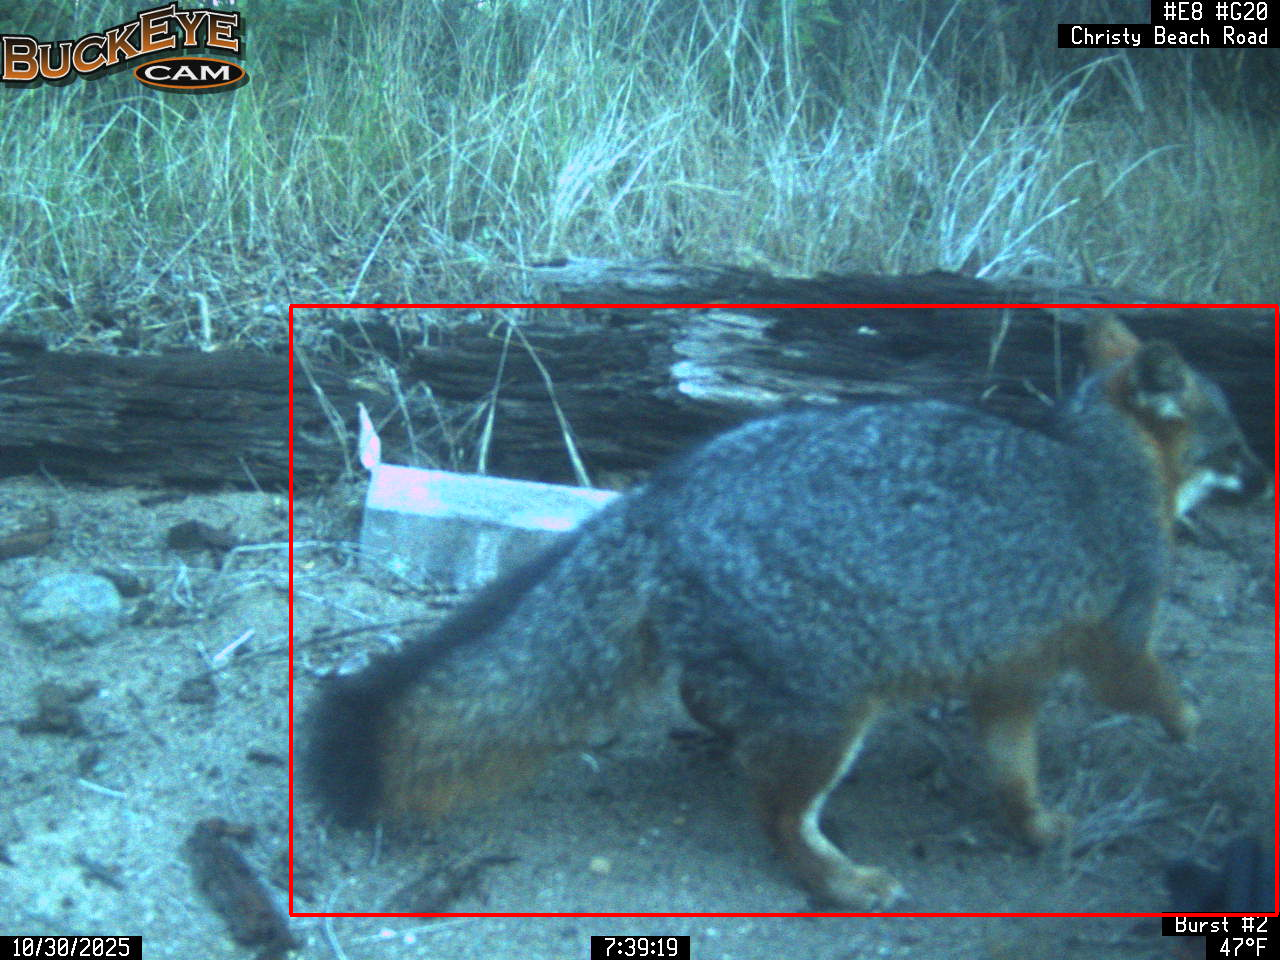

In [56]:
pth = '../../models/megadetectorv1000/fox_test.jpg'

with open(pth, "rb") as f:
    image_data = f.read()
res = requests.put('http://127.0.0.1:8080/invocations', data=image_data)

res = res.json()
res = res[0]


request_image = Image.open(pth)
draw_bounding_box_on_image(request_image, res['y1'], res['x1'], res['y2'], res['x2'], res['class']) 

request_image